# Assignment: Trees
Do three questions.

**Q1.** Please answer the following questions in your own words.

1. How are trees constructed?

2. How do trees handle non-linear relationships between variables? Compare this to linear models. 

3. Why is the Gini a good loss function for categorical target variables? 

4. Why do trees tend to overfit, and how can this tendency be constrained? 

5. True or false, and explain: Trees only really perform well in situations with lots of categorical variables as features/covariates. 

6. Why don't most versions of classification/regression tree concept allow for more than two branches after a split?

7. What are some heuristic ways you can examine a tree and decide whether it is probably over- or under-fitting?

1. Trees are made by creating an algorithm that chooses certain features to split the data. 
2. Trees are able to handle non-linear relationships well because they are able to learn boundaries based on the data itself. Linear models are not as good as handling non-linear relationships between variables in comparison. 
3. It is a good loss function because it favors pure splits, which is desirable for categorical variables. 
4. Trees tend to overfit due to noise, especially if the dataset is messy. In order to fix this, datasets should be properly cleaned. 
5. False: Trees can handle categorical/continuous variables well because they are able to classify non-linear interactions. 
6. It is easier to interpret. Also, multiple splits can lead to overfitting. 
7. A tree is overfitting if the tree has a lot ofbranches, or high training accuracy and low test accuracy. A tree is underfitting if the accuracy is low for training. 

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.tree import plot_tree
from sklearn.linear_model import LinearRegression

**Q2.** This is a case study on regression and classification trees.

1. Load `./data/cars_hw.csv`. How many observations and features/covariates/variables? What are the available variables? Take a look at the first few rows of data.

2. For the categorical variables `Make`, `Color`, `Body_type`, `No_of_Owners`, `Fuel_Type`, `Transmission`, and `Transmission_Type`, create dummy/one-hot-encoded representations. For numeric variables, we'll use `Mileage_Run`, `Make_Year`, and `Seating_Capacity`. Our target variable will be `Price`. Make a train-test split of your data.

3. From `sklearn.tree`, import the `DecisionTreeRegressor` and `plot_tree`. Use a train-test split to iterate over possible values for `min_samples_leaf`, computing the $R^2$ for each value between 1 and 25. What choice achieves the highest $R^2$ on the test data?

4. For the optimal `min_samples_leaf` from 3, regress price on the rest of the features/covariates using the training data. What is your $R^2$ and RMSE on the test set? Plot the dendrogram. Plot the residuals. Is the density of residuals symmetric and centered around 0?

4. Run a linear regression of price on the same variables. Which model -- regression tree or linear regression -- performs better on the test set? Why?

5. Predict prices using both your tree and your linear model, and make a scatter plot of their values. Describe what you see. 

In [27]:
cars_df = pd.read_csv('cars_hw.csv')
print(cars_df.head())
cars_df.shape

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000  


(976, 12)

In [28]:
#one-hot encode variables
cars_df['No_of_Owners'] = cars_df['No_of_Owners'].map({'1st': 1, '2nd': 2, '3rd': 3, '4th': 4})
categoricals = ['Make', 'Color', 'Body_Type', 'Fuel_Type', 'Transmission', 'Transmission_Type']
cars_encoded = pd.get_dummies(cars_df, columns=categoricals, drop_first=True)

#features
features = ['Mileage_Run', 'Make_Year', 'Seating_Capacity', 'No_of_Owners']
X = cars_encoded[features + [col for col in cars_encoded.columns if col not in features + ['Price']]]

#target
y = cars_df['Price']

In [29]:
#train test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

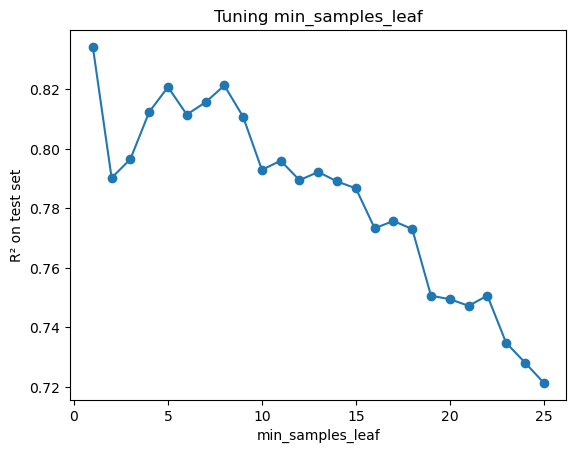

Best min_samples_leaf: 1


In [34]:
r2_scores = []

#r2 values
for leaf in range(1, 26):
    tree = DecisionTreeRegressor(min_samples_leaf=leaf, random_state=42)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

#plot r2
plt.plot(range(1, 26), r2_scores, marker='o')
plt.xlabel("min_samples_leaf")
plt.ylabel("R² on test set")
plt.title("Tuning min_samples_leaf")
plt.show()

#find best value
best_leaf = r2_scores.index(max(r2_scores)) + 1
print("Best min_samples_leaf:", best_leaf)

Decision Tree R²: 0.8343220249151776
Decision Tree RMSE: 137849.6111932219


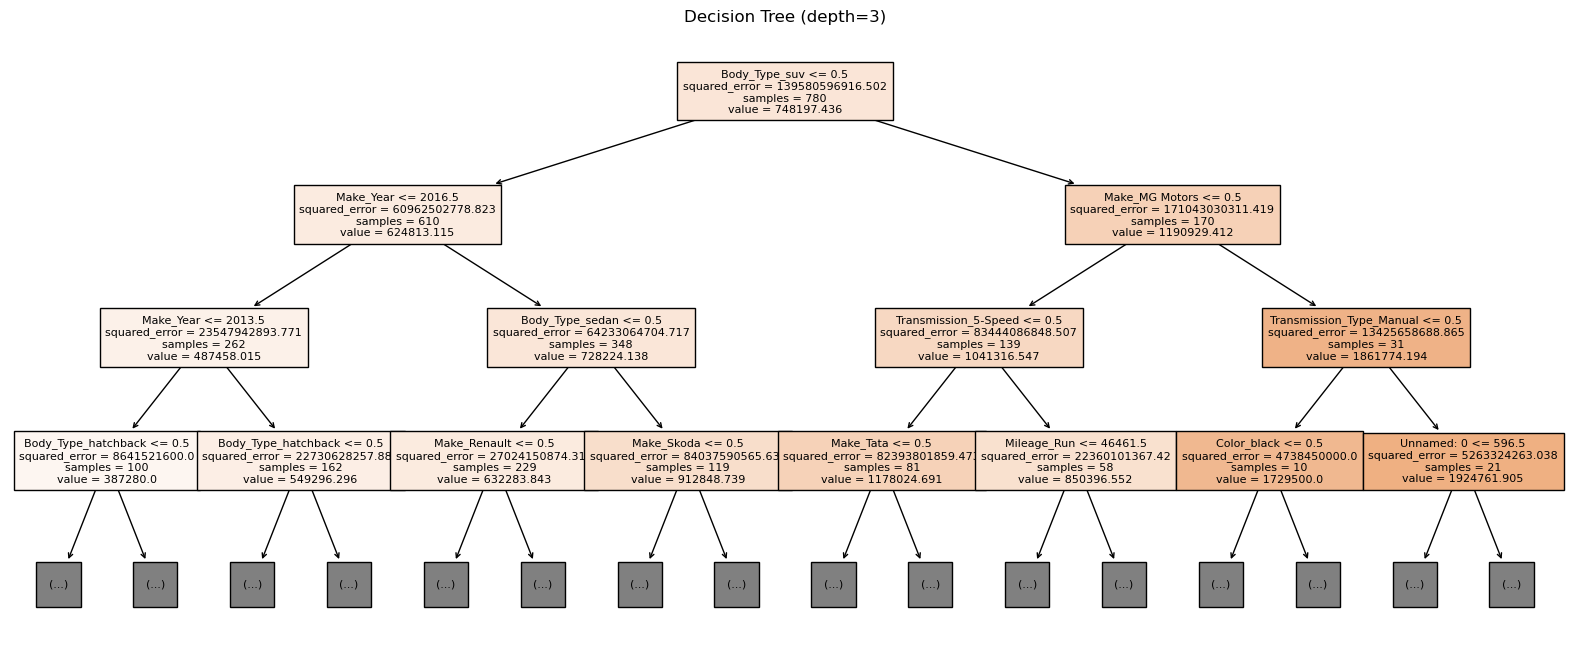

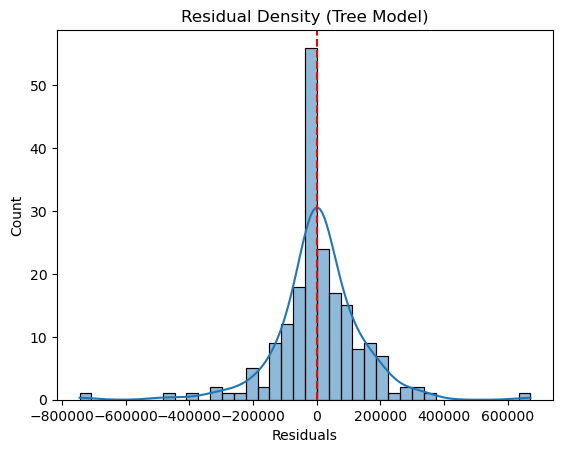

In [35]:
final_tree = DecisionTreeRegressor(min_samples_leaf=1, random_state=42)
final_tree.fit(X_train, y_train)
y_pred_tree = final_tree.predict(X_test)
r2_tree = r2_score(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))

print("Decision Tree R²:", r2_tree)
print("Decision Tree RMSE:", rmse_tree)

#dendrogram
plt.figure(figsize=(20, 8))
plot_tree(final_tree, feature_names=X.columns, filled=True, max_depth=3, fontsize=8)
plt.title("Decision Tree (depth=3)")
plt.show()

#residuals plot
residuals = y_test - y_pred_tree
sns.histplot(residuals, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Residual Density (Tree Model)")
plt.xlabel("Residuals")
plt.show()

Plot of tree is (somewhat) symmetric and centered around 0!

In [24]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_lin = linear_model.predict(X_test)

r2_lin = r2_score(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))

print("Linear Regression R²:", r2_lin)
print("Linear Regression RMSE:", rmse_lin)

Linear Regression R²: 0.8157593725785882
Linear Regression RMSE: 145367.01026688353


The regression tree did better than the linear model

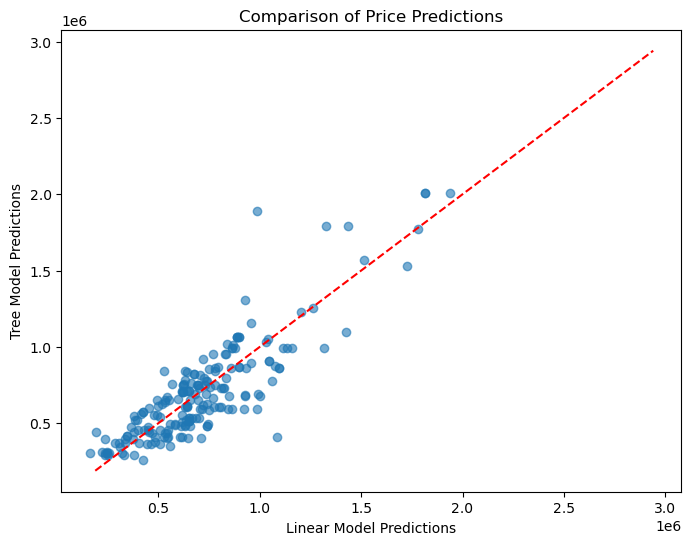

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_lin, y_pred_tree, alpha=0.6)
plt.xlabel("Linear Model Predictions")
plt.ylabel("Tree Model Predictions")
plt.title("Comparison of Price Predictions")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # y = x line
plt.show()

**Q3.** This is a case study about classification and regression trees.

1. Load the `Breast Cancer METABRIC.csv` dataset. How many observations and variables does it contain? Print out the first few rows of data.

2.  We'll use a consistent set of feature/explanatory variables. For numeric variables, we'll include `Tumor Size`, `Lymph nodes examined positive`, `Age at Diagnosis`. For categorical variables, we'll include `Tumor Stage`, `Chemotherapy`, and `Cancer Type Detailed`. One-hot-encode the categorical variables and concatenate them with the numeric variables into a feature/covariate matrix, $X$.

3. Let's predict `Overall Survival Status` given the features/covariates $X$. There are 528 missing values, unfortunately: Either drop those rows from your data or add them as a category to predict. Constrain the minimum samples per leaf to 10. Print a dendrogram of the tree. Print a confusion matrix of the algorithm's performance. What is the accuracy? 

4. For your model in part three, compute three statistics:
    - The **true positive rate** or **sensitivity**:
        $$
        TPR = \dfrac{TP}{TP+FN}
        $$
    - The **true negative rate** or **specificity**:
        $$
        TNR = \dfrac{TN}{TN+FP}
        $$
    Does your model tend to perform better with respect to one of these metrics?

5. Let's predict `Overall Survival (Months)` given the features/covariates $X$. Use the train/test split to pick the optimal `min_samples_leaf` value that gives the highest $R^2$ on the test set (it's about 110). What is the $R^2$? Plot the test values against the predicted values. How do you feel about this model for clinical purposes?

**Q4.** This is a case study about trees using bond rating data. This is a dataset about bond ratings for different companies, alongside a bunch of business statistics and other data. Companies often have multiple reviews at different dates. We want to predict the bond rating (AAA, AA, A, BBB, BB, B, ..., C, D). Do business fundamentals predict the company's rating?

1. Load the `./data/corporate_ratings.csv` dataset. How many observations and variables does it contain? Print out the first few rows of data.

2.  Plot a histogram of the `ratings` variable. It turns out that the gradations of AAA/AA/A and BBB/BB/B and so on make it hard to get good results with trees. Collapse all AAA/AA/A ratings into just A, and similarly for B and C.

3. Use all of the variables **except** Rating, Date, Name, Symbol, and Rating Agency Name. To include Sector, make a dummy/one-hot-encoded representation and include it in your features/covariates. Collect the relevant variables into a data matrix $X$. 

4. Do a train/test split of the data and use a decision tree classifier to predict the bond rating. Including a min_samples_leaf constraint can raise the accuracy and speed up computation time. Print a confusion matrix and the accuracy of your model. How well do you predict the different bond ratings?

5. If you include the rating agency as a feature/covariate/predictor variable, do the results change? How do you interpret this?

In [40]:
corporate_df = pd.read_csv('corporate_ratings.csv')
corporate_df.head()

,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,11/27/2015,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2/13/2014,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,3/6/2015,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,6/15/2012,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,10/24/2016,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


In [41]:
print(corporate_df.shape)

(2029, 31)


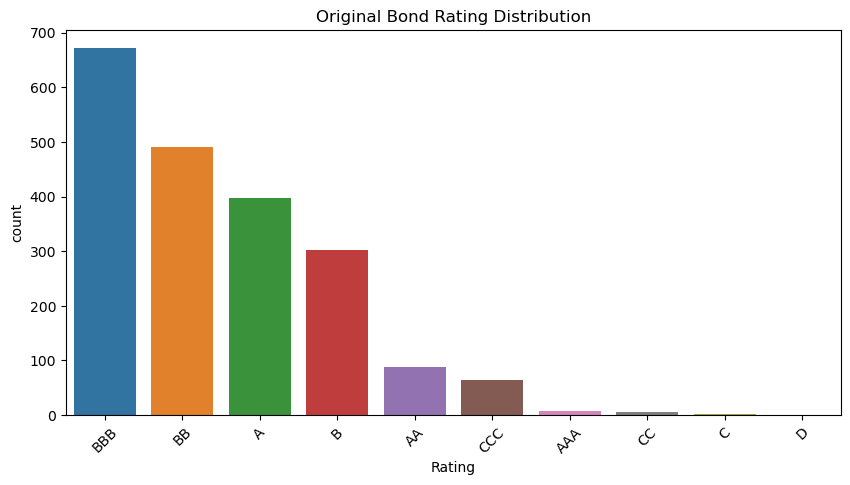

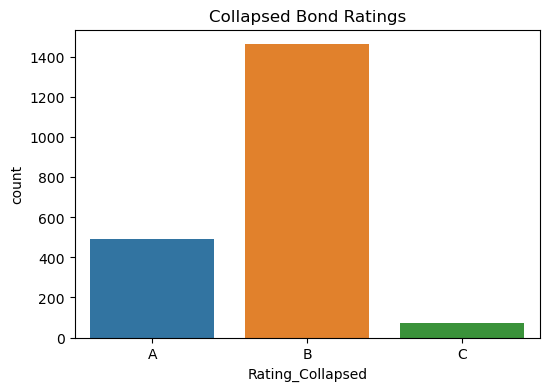

In [42]:
#original distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=corporate_df, x='Rating', order=corporate_df['Rating'].value_counts().index)
plt.title('Original Bond Rating Distribution')
plt.xticks(rotation=45)
plt.show()

#collapse ratings
def collapse_rating(r):
    if r in ['AAA', 'AA', 'A']:
        return 'A'
    elif r in ['BBB', 'BB', 'B']:
        return 'B'
    elif r in ['CCC', 'CC', 'C', 'D']:
        return 'C'
    else:
        return r

corporate_df['Rating_Collapsed'] = corporate_df['Rating'].apply(collapse_rating)

#collapse distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=corporate_df, x='Rating_Collapsed', order=['A', 'B', 'C'])
plt.title('Collapsed Bond Ratings')
plt.show()

In [43]:
#drop non-feature columns
features = corporate_df.drop(columns=['Rating', 'Date', 'Name', 'Symbol', 'Rating Agency Name', 'Rating_Collapsed'])

#one-hot encode
X = pd.get_dummies(features)

#target
y = corporate_df['Rating_Collapsed']

Accuracy: 0.6995073891625616


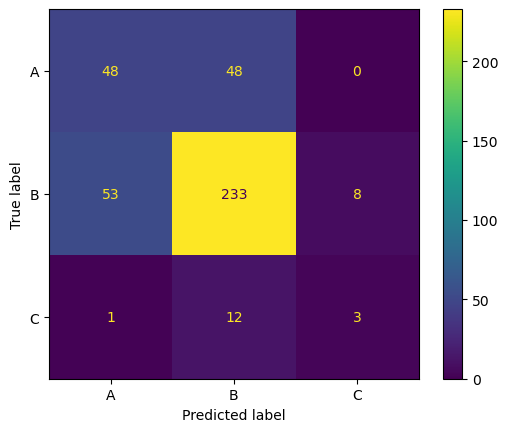

In [44]:
#split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#reduce overfitting
tree = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

#confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['A', 'B', 'C'])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['A', 'B', 'C']).plot()

#accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy with rating agency included: 0.7610837438423645


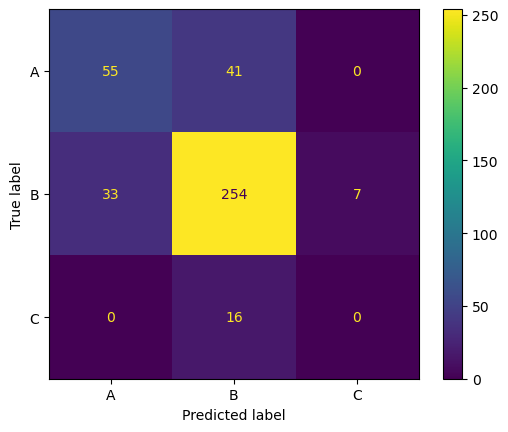

In [45]:
#include Rating Agency Name
features_plus_agency = corporate_df.drop(columns=['Rating', 'Date', 'Name', 'Symbol', 'Rating_Collapsed'])
X_plus = pd.get_dummies(features_plus_agency)

#spi t
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_plus, y, test_size=0.2, random_state=42)

#train 
tree2 = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
tree2.fit(X_train2, y_train2)

y_pred2 = tree2.predict(X_test2)

cm2 = confusion_matrix(y_test2, y_pred2, labels=['A', 'B', 'C'])
ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['A', 'B', 'C']).plot()

print("Accuracy with rating agency included:", accuracy_score(y_test2, y_pred2))

The accuracy improved, possibly because the rating agency may have introduced systemic bias or other patterns. 

**Q5.** This is a case study about detecting fraud using classification trees. The goal is to predict the `class` variable, which is 0 for non-fraud and 1 for fraud.

1. Open `./data/creditcard_fraud.csv`. Print the number of observations and variables, and look at the first few rows of data. The variables are already normalized and de-identified, and are just called things like `V8` to protect the privacy of the clients.

2. Print a table of counts for the `class` variable and make a histogram. What percentage of transactions are fraudulent?

3. Drop `Time` and make a decision tree classifier to predict fraud. Print a confusion table and compute the accuracy. This is a serious **class imbalance** problem: The minority class is so small that essentially predicting 0's for all cases will achieve an extremely high accuracy. There are over-sampling techniques to deal with this issue, but we don't have time to cover them in class.

4. Imagine that you block every transaction in the test set labelled as fraudulent. How much money is (1) saved that should be saved, (2) lost to fraud anyway, (3) withheld in error from customers? Does implementing this anti-fraud system seem like a good idea, or not? Why?

5. Instead of predicting fraud, predict loss: Multiple the `Class` variable times the `Amount` variable, and call it `Loss`. Predict it using a decision tree regressor (making sure to drop Class, Time, and Loss from the features/covariates/predictors). What $R^2$ and RMSE do you get? Make a scatterplot of the predicted values on the test group versus the actual test values. Do you notice any interesting patterns? How could you use this algorithm to decide which transactions to block, and why?


**Q6.** Show that any decision tree is equivalent to a linear regression on a set of dummy variables that represent the optimal splits in the tree. 

Hint: You can think of CART as partitioning the feature space into a set of sets $\{S_1, S_2, ..., S_K\}$, and then predicting the average for all of the observations in each set $S_k$, $m_k$:
$$
\hat{y}(x) = \sum_{k=1}^K \mathbb{I}\{ x \text{ is in } S_k \} m_k
$$
where $\mathbb{I} \{ P(x,k)\}$ takes the value 1 if the proposition $P(x,k)$ is true and 0 otherwise. Now, doesn't that look like least-squares regression on a set of dummy/one-hot-encoded variables?

Conversely, can any linear regression be represented by a tree?